# Step 5 - Feature Engineering

Goal:
- Build a robust feature engineering pipeline for binary default prediction.
- Keep transformations scalable with PySpark and production-ready conventions.

This notebook includes:
1. Data cleaning
2. Target engineering
3. Feature creation
4. Encoding and transformation pipeline
5. Feature selection
6. Class imbalance analysis
7. Gold feature table write
8. Executive summary

In [1]:
import importlib.util
import os
import subprocess
import sys

STRICT_DELTA_REQUIRED = os.getenv("STEP5_STRICT_DELTA_REQUIRED", "1") == "1"

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "pyspark": "pyspark",
    "delta": "delta-spark"
}

missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
    print("Package installation completed.")
else:
    print("All core feature engineering packages are already installed.")

if STRICT_DELTA_REQUIRED:
    print("Strict Delta mode is active: Step 5 requires Delta Lake output.")
else:
    print("Strict Delta mode is disabled via STEP5_STRICT_DELTA_REQUIRED=0.")

All core feature engineering packages are already installed.
Strict Delta mode is active: Step 5 requires Delta Lake output.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")
sns.set_palette("tab10")

In [3]:
from pyspark import SparkContext

APP_NAME = "CreditRisk-Step5-FeatureEngineering"
WORKSPACE_ROOT = "c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main"

LOCAL_SHUFFLE_PARTITIONS = int(os.getenv("SPARK_LOCAL_SHUFFLE_PARTITIONS", "32"))
LOCAL_DEFAULT_PARALLELISM = int(os.getenv("SPARK_LOCAL_DEFAULT_PARALLELISM", "32"))
LOCAL_DRIVER_MEMORY = os.getenv("SPARK_LOCAL_DRIVER_MEMORY", "6g")
LOCAL_DRIVER_MAX_RESULT = os.getenv("SPARK_LOCAL_DRIVER_MAX_RESULT", "1g")
SPARK_LOCAL_DIR = os.getenv("SPARK_LOCAL_DIR", f"{WORKSPACE_ROOT}/tmp/spark-local")
STRICT_DELTA_REQUIRED = os.getenv("STEP5_STRICT_DELTA_REQUIRED", "1") == "1"
os.makedirs(SPARK_LOCAL_DIR, exist_ok=True)

def ensure_windows_hadoop_home(workspace_root: str):
    if os.name != "nt":
        return None

    candidate_homes = []
    env_home = os.environ.get("HADOOP_HOME") or os.environ.get("hadoop.home.dir")
    if env_home:
        candidate_homes.append(env_home)
    candidate_homes.append(f"{workspace_root}/third_party/hadoop")

    for home in candidate_homes:
        winutils_path = os.path.join(home, "bin", "winutils.exe")
        if os.path.exists(winutils_path):
            os.environ["HADOOP_HOME"] = home
            os.environ["hadoop.home.dir"] = home
            os.environ["PATH"] = os.path.join(home, "bin") + ";" + os.environ.get("PATH", "")
            return home

    target_home = candidate_homes[-1]
    target_bin = os.path.join(target_home, "bin")
    target_winutils = os.path.join(target_bin, "winutils.exe")
    os.makedirs(target_bin, exist_ok=True)

    download_urls = [
        "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.5/bin/winutils.exe",
        "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.4/bin/winutils.exe",
        "https://github.com/steveloughran/winutils/raw/master/hadoop-3.0.0/bin/winutils.exe"
    ]

    import urllib.request
    last_error = None
    for url in download_urls:
        try:
            urllib.request.urlretrieve(url, target_winutils)
            if os.path.exists(target_winutils) and os.path.getsize(target_winutils) > 0:
                os.environ["HADOOP_HOME"] = target_home
                os.environ["hadoop.home.dir"] = target_home
                os.environ["PATH"] = target_bin + ";" + os.environ.get("PATH", "")
                return target_home
        except Exception as exc:
            last_error = exc

    raise RuntimeError(
        "winutils.exe could not be prepared automatically. "
        "Set HADOOP_HOME to a folder containing bin/winutils.exe and rerun this cell."
    ) from last_error

def reset_pyspark_runtime_state():
    try:
        SparkContext._active_spark_context = None
        SparkContext._gateway = None
        SparkContext._jvm = None
    except Exception:
        pass
    try:
        SparkSession._instantiatedSession = None
        SparkSession._activeSession = None
    except Exception:
        pass

hadoop_home = ensure_windows_hadoop_home(WORKSPACE_ROOT)
if hadoop_home:
    print(f"Using HADOOP_HOME: {hadoop_home}")

try:
    from delta import configure_spark_with_delta_pip
except Exception as delta_import_error:
    raise RuntimeError(
        "delta-spark import failed. Step 5 requires Delta Lake output. "
        "Install delta-spark and rerun."
    ) from delta_import_error

DELTA_RUNTIME_AVAILABLE = True

reset_pyspark_runtime_state()
base_builder = (
    SparkSession.builder
    .master("local[*]")
    .appName(APP_NAME)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.shuffle.partitions", str(LOCAL_SHUFFLE_PARTITIONS))
    .config("spark.default.parallelism", str(LOCAL_DEFAULT_PARALLELISM))
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.ansi.enabled", "false")
    .config("spark.driver.memory", LOCAL_DRIVER_MEMORY)
    .config("spark.driver.maxResultSize", LOCAL_DRIVER_MAX_RESULT)
    .config("spark.python.worker.reuse", "true")
    .config("spark.local.dir", SPARK_LOCAL_DIR)
)

spark_builder = (
    base_builder
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
)

try:
    spark = configure_spark_with_delta_pip(spark_builder).getOrCreate()
except Exception as delta_startup_error:
    if STRICT_DELTA_REQUIRED:
        raise RuntimeError(
            "Delta-enabled Spark session could not start. "
            "Step 5 requires Delta Lake write; run this notebook in a compatible Spark runtime "
            "(Docker/Linux Spark environment recommended)."
        ) from delta_startup_error
    DELTA_RUNTIME_AVAILABLE = False
    spark = base_builder.getOrCreate()

if STRICT_DELTA_REQUIRED and not DELTA_RUNTIME_AVAILABLE:
    raise RuntimeError("Strict Delta mode requires DELTA_RUNTIME_AVAILABLE=True.")

spark.conf.set("spark.sql.ansi.enabled", "false")
spark.sparkContext.setLogLevel("WARN")
print(f"Delta runtime available: {DELTA_RUNTIME_AVAILABLE}")
print(f"Strict Delta required: {STRICT_DELTA_REQUIRED}")
print(
    "Spark local profile -> "
    f"shuffle={LOCAL_SHUFFLE_PARTITIONS}, parallelism={LOCAL_DEFAULT_PARALLELISM}, "
    f"driver_memory={LOCAL_DRIVER_MEMORY}, max_result={LOCAL_DRIVER_MAX_RESULT}"
)

def hdfs_path_exists(path: str) -> bool:
    if not path:
        return False
    try:
        jvm = spark._jvm
        fs = jvm.org.apache.hadoop.fs.FileSystem.get(spark._jsc.hadoopConfiguration())
        return bool(fs.exists(jvm.org.apache.hadoop.fs.Path(path)))
    except Exception:
        return os.path.exists(path)

def first_existing_path(candidates):
    for p in candidates:
        if p and hdfs_path_exists(p):
            return p
    return None

def resolve_delta_base():
    candidates = []
    env_base = os.getenv("DELTA_BASE")
    if env_base:
        candidates.append(env_base)
    candidates.extend([
        f"{WORKSPACE_ROOT}/delta_lake",
        "/app/delta_lake",
        "delta_lake",
        "../delta_lake"
    ])
    for p in candidates:
        if hdfs_path_exists(p):
            return p
    return f"{WORKSPACE_ROOT}/delta_lake"

DELTA_BASE = resolve_delta_base()
RAW_CSV_CANDIDATES = [
    f"{WORKSPACE_ROOT}/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "/app/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "../data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv",
    "data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv"
]

GOOD_STATUSES = ["Fully Paid"]
BAD_STATUSES = ["Charged Off", "Default", "Late (31-120 days)"]

LEAKAGE_COLS = [
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d", "last_credit_pull_d",
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "hardship_amount", "settlement_status", "settlement_amount",
    "settlement_percentage", "settlement_term",
    "debt_settlement_flag", "debt_settlement_flag_date"
]

Using HADOOP_HOME: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/third_party/hadoop
Delta runtime available: True
Strict Delta required: True
Spark local profile -> shuffle=32, parallelism=32, driver_memory=6g, max_result=1g


In [4]:
MAX_NOTEBOOK_ROWS = int(os.getenv("STEP5_MAX_NOTEBOOK_ROWS", "450000"))
SAMPLE_SEED = int(os.getenv("STEP5_SAMPLE_SEED", "42"))

raw_path = first_existing_path(RAW_CSV_CANDIDATES)
if raw_path is None:
    raise FileNotFoundError("Lending Club CSV file was not found in expected paths.")

raw_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(raw_path)
)

required_columns = [
    "id", "member_id", "loan_status", "issue_d",
    "loan_amnt", "term", "int_rate", "installment",
    "annual_inc", "dti", "fico_range_high", "revol_util",
    "open_acc", "pub_rec", "purpose", "home_ownership",
    "emp_length", "verification_status", "delinq_2yrs", "total_acc",
    "grade", "sub_grade"
]
selected_cols = [c for c in list(dict.fromkeys(required_columns + LEAKAGE_COLS)) if c in raw_df.columns]
base_df = raw_df.select(*selected_cols)

rows_before_sampling = base_df.count()
if rows_before_sampling > MAX_NOTEBOOK_ROWS:
    sample_fraction = MAX_NOTEBOOK_ROWS / float(rows_before_sampling)
    base_df = (
        base_df
        .sample(withReplacement=False, fraction=sample_fraction, seed=SAMPLE_SEED)
        .persist(StorageLevel.DISK_ONLY)
    )
    rows_after_sampling = base_df.count()
    print(
        "Applied local sampling for stability: "
        f"{rows_after_sampling:,}/{rows_before_sampling:,} rows ({sample_fraction:.2%})"
    )
else:
    rows_after_sampling = rows_before_sampling
    base_df = base_df.persist(StorageLevel.DISK_ONLY)
    print(f"Sampling skipped: dataset within threshold ({rows_after_sampling:,} rows).")

print(f"Resolved raw data path: {raw_path}")
print(f"Rows in raw dataset: {rows_before_sampling:,}")
print(f"Rows in selected base dataframe: {rows_after_sampling:,}")
print(f"Selected columns: {len(base_df.columns)}")

Applied local sampling for stability: 449,571/2,260,701 rows (19.91%)
Resolved raw data path: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv
Rows in raw dataset: 2,260,701
Rows in selected base dataframe: 449,571
Selected columns: 46


## 1) Data Cleaning

Cleaning actions:
- duplicate removal
- null handling
- datatype fixing
- percentage string cleaning
- `emp_length` numeric parsing
- `term` numeric conversion
- datetime conversion
- leakage column removal

Leakage rationale:
- Post-outcome payment/recovery fields contain future information and can make model performance unrealistically high.
- These columns are unavailable at application-time scoring, so they must be removed.

In [5]:
def parse_percent(col_name):
    col_str = F.trim(F.col(col_name).cast("string"))
    numeric_str = F.regexp_extract(col_str, r"^([+-]?\d+(?:\.\d+)?)%?$", 1)
    return F.when(F.length(numeric_str) > 0, numeric_str.cast("double")).otherwise(F.lit(None).cast("double"))

def parse_emp_length(col_name):
    raw = F.trim(F.col(col_name).cast("string"))
    return (
        F.when(raw.isNull(), F.lit(None).cast("int"))
         .when(raw == "< 1 year", F.lit(0))
         .when(raw == "10+ years", F.lit(10))
         .otherwise(F.regexp_extract(raw, r"(\d+)", 1).cast("int"))
    )

clean_df = base_df

if "id" in clean_df.columns:
    clean_df = clean_df.dropDuplicates(["id"] )
elif "member_id" in clean_df.columns:
    clean_df = clean_df.dropDuplicates(["member_id"] )
else:
    clean_df = clean_df.dropDuplicates()

clean_df = (
    clean_df
    .withColumn("loan_amnt", F.col("loan_amnt").cast("double"))
    .withColumn("installment", F.col("installment").cast("double"))
    .withColumn("annual_inc", F.col("annual_inc").cast("double"))
    .withColumn("dti", F.col("dti").cast("double"))
    .withColumn("fico_range_high", F.col("fico_range_high").cast("double"))
    .withColumn("open_acc", F.col("open_acc").cast("double"))
    .withColumn("pub_rec", F.col("pub_rec").cast("double"))
    .withColumn("delinq_2yrs", F.col("delinq_2yrs").cast("double"))
    .withColumn("total_acc", F.col("total_acc").cast("double"))
    .withColumn("int_rate_num", parse_percent("int_rate"))
    .withColumn("revol_util_num", parse_percent("revol_util"))
    .withColumn("term_num", F.regexp_extract(F.col("term").cast("string"), r"(\d+)", 1).cast("int"))
    .withColumn("emp_length_num", parse_emp_length("emp_length"))
    .withColumn("issue_date", F.to_date(F.col("issue_d"), "MMM-yyyy"))
)

leakage_cols_existing = [c for c in LEAKAGE_COLS if c in clean_df.columns]
clean_df = clean_df.drop(*leakage_cols_existing)

numeric_impute_cols = [
    "loan_amnt", "installment", "annual_inc", "dti", "fico_range_high",
    "open_acc", "pub_rec", "delinq_2yrs", "total_acc",
    "int_rate_num", "revol_util_num", "term_num", "emp_length_num"
]
numeric_impute_cols = [c for c in numeric_impute_cols if c in clean_df.columns]

median_map = {}
for c in numeric_impute_cols:
    q = clean_df.approxQuantile(c, [0.5], 0.01)
    if q:
        median_map[c] = float(q[0])

clean_df = clean_df.na.fill(median_map)

categorical_fill_cols = ["purpose", "home_ownership", "verification_status", "term", "emp_length", "grade", "sub_grade"]
categorical_fill_cols = [c for c in categorical_fill_cols if c in clean_df.columns]
categorical_fill_map = {c: "UNKNOWN" for c in categorical_fill_cols}
clean_df = clean_df.na.fill(categorical_fill_map)

clean_df = clean_df.filter(F.col("loan_status").isNotNull())
clean_df = clean_df.persist(StorageLevel.DISK_ONLY)

print(f"Rows after cleaning: {clean_df.count():,}")
print(f"Columns after leakage drop: {len(clean_df.columns)}")
print(f"Leakage columns dropped: {len(leakage_cols_existing)}")
if leakage_cols_existing:
    print(", ".join(leakage_cols_existing))

Rows after cleaning: 449,565
Columns after leakage drop: 27
Leakage columns dropped: 24
out_prncp, out_prncp_inv, total_pymnt, total_pymnt_inv, total_rec_prncp, total_rec_int, total_rec_late_fee, recoveries, collection_recovery_fee, last_pymnt_d, last_pymnt_amnt, next_pymnt_d, last_credit_pull_d, hardship_flag, hardship_type, hardship_reason, hardship_status, hardship_amount, settlement_status, settlement_amount, settlement_percentage, settlement_term, debt_settlement_flag, debt_settlement_flag_date


## 2) Target Engineering

Mapping rule:
- GOOD LOAN = 0 -> Fully Paid
- BAD LOAN = 1 -> Charged Off, Default, Late (31-120 days)
- Other statuses are dropped

Dropped statuses and counts:
+---------------------------------------------------+------+
|loan_status                                        |count |
+---------------------------------------------------+------+
|Current                                            |174749|
|In Grace Period                                    |1651  |
|Late (16-30 days)                                  |842   |
|Does not meet the credit policy. Status:Fully Paid |398   |
|Does not meet the credit policy. Status:Charged Off|160   |
+---------------------------------------------------+------+

+------+------+
|target| count|
+------+------+
|     0|214164|
|     1| 57601|
+------+------+

GOOD count: 214,164
BAD count: 57,601
BAD rate: 21.20%
Imbalance ratio (GOOD/BAD): 3.72


c:\Users\MONSTER\AppData\Local\Programs\Python\Python310\lib\site-packages\pyspark\sql\pandas\conversion.py:94: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 15.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


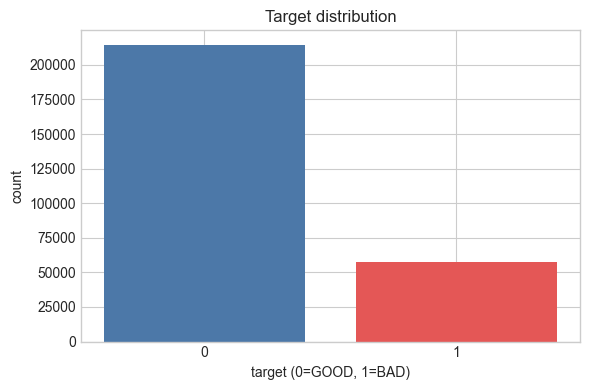

In [6]:
status_mapped_df = clean_df.withColumn(
    "target",
    F.when(F.col("loan_status").isin(BAD_STATUSES), F.lit(1))
     .when(F.col("loan_status").isin(GOOD_STATUSES), F.lit(0))
     .otherwise(F.lit(None).cast("int"))
)

dropped_status_df = (
    status_mapped_df.filter(F.col("target").isNull())
    .groupBy("loan_status")
    .count()
    .orderBy(F.desc("count"))
)

target_df = (
    status_mapped_df
    .filter(F.col("target").isNotNull())
    .withColumn("target", F.col("target").cast("int"))
    .persist(StorageLevel.DISK_ONLY)
)

print("Dropped statuses and counts:")
dropped_status_df.show(30, truncate=False)

target_dist_df = target_df.groupBy("target").count().orderBy("target")
target_dist_df.show()

target_counts = {int(r["target"]): int(r["count"]) for r in target_dist_df.collect()}
good_count = target_counts.get(0, 0)
bad_count = target_counts.get(1, 0)
total_count = good_count + bad_count

print(f"GOOD count: {good_count:,}")
print(f"BAD count: {bad_count:,}")
print(f"BAD rate: {(bad_count / total_count):.2%}")
print(f"Imbalance ratio (GOOD/BAD): {(good_count / max(bad_count, 1)):.2f}")

target_plot_pdf = target_dist_df.toPandas()
plt.figure(figsize=(6, 4))
plt.bar(target_plot_pdf["target"].astype(str), target_plot_pdf["count"], color=["#4C78A8", "#E45756"])
plt.title("Target distribution")
plt.xlabel("target (0=GOOD, 1=BAD)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 3) Feature Creation

New engineered features and business logic:
1. `income_to_loan_ratio`: repayment capacity relative to requested amount.
2. `credit_stress_score`: combined stress from DTI, utilization, and interest rate.
3. `fico_bucket`: interpretable credit-score bands.
4. `high_risk_purpose_flag`: marks historically riskier usage purposes.
5. `employment_stability_score`: employment tenure converted to stability signal.
6. `credit_utilization_risk`: bucketized utilization pressure.
7. `installment_income_ratio`: monthly installment burden vs monthly income.
8. `delinquency_risk_score`: delinquency/public record composite risk metric.

In [7]:
high_risk_purposes = ["small_business", "debt_consolidation", "medical", "moving", "vacation", "renewable_energy"]

safe_annual_inc = F.when(F.col("annual_inc") <= 0, F.lit(1.0)).otherwise(F.col("annual_inc"))
safe_loan_amnt = F.when(F.col("loan_amnt") <= 0, F.lit(1.0)).otherwise(F.col("loan_amnt"))
monthly_income = safe_annual_inc / F.lit(12.0)

fe_df = (
    target_df
    .withColumn("income_to_loan_ratio", safe_annual_inc / safe_loan_amnt)
    .withColumn(
        "credit_stress_score",
        F.round(
            F.greatest(
                F.lit(0.0),
                F.least(
                    F.lit(100.0),
                    (
                        F.coalesce(F.col("dti"), F.lit(0.0)) / F.lit(40.0) * F.lit(0.35) +
                        F.coalesce(F.col("revol_util_num"), F.lit(0.0)) / F.lit(100.0) * F.lit(0.35) +
                        F.coalesce(F.col("int_rate_num"), F.lit(0.0)) / F.lit(30.0) * F.lit(0.30)
                    ) * F.lit(100.0)
                )
            ),
            2
        )
    )
    .withColumn(
        "fico_bucket",
        F.when(F.col("fico_range_high") < 640, F.lit("poor"))
         .when(F.col("fico_range_high") < 680, F.lit("fair"))
         .when(F.col("fico_range_high") < 720, F.lit("good"))
         .when(F.col("fico_range_high") < 760, F.lit("very_good"))
         .otherwise(F.lit("excellent"))
    )
    .withColumn(
        "high_risk_purpose_flag",
        F.when(F.lower(F.col("purpose")).isin(high_risk_purposes), F.lit(1)).otherwise(F.lit(0))
    )
    .withColumn(
        "employment_stability_score",
        F.when(F.col("emp_length_num") <= 0, F.lit(0))
         .when(F.col("emp_length_num") <= 1, F.lit(1))
         .when(F.col("emp_length_num") <= 3, F.lit(2))
         .when(F.col("emp_length_num") <= 6, F.lit(3))
         .when(F.col("emp_length_num") <= 9, F.lit(4))
         .otherwise(F.lit(5))
    )
    .withColumn(
        "credit_utilization_risk",
        F.when(F.col("revol_util_num") <= 30, F.lit("low"))
         .when(F.col("revol_util_num") <= 60, F.lit("moderate"))
         .when(F.col("revol_util_num") <= 85, F.lit("high"))
         .otherwise(F.lit("severe"))
    )
    .withColumn("installment_income_ratio", F.col("installment") / monthly_income)
    .withColumn("delinquency_risk_score", F.coalesce(F.col("delinq_2yrs"), F.lit(0.0)) * 2.0 + F.coalesce(F.col("pub_rec"), F.lit(0.0)) * 3.0)
)

engineered_cols = [
    "income_to_loan_ratio", "credit_stress_score", "fico_bucket",
    "high_risk_purpose_flag", "employment_stability_score",
    "credit_utilization_risk", "installment_income_ratio",
    "delinquency_risk_score"
]

fe_df = fe_df.persist(StorageLevel.DISK_ONLY)
print(f"Rows after feature creation: {fe_df.count():,}")
fe_df.select(*(engineered_cols + ["target"])) .show(10, truncate=False)

Rows after feature creation: 271,765
+--------------------+-------------------+-----------+----------------------+--------------------------+-----------------------+------------------------+----------------------+------+
|income_to_loan_ratio|credit_stress_score|fico_bucket|high_risk_purpose_flag|employment_stability_score|credit_utilization_risk|installment_income_ratio|delinquency_risk_score|target|
+--------------------+-------------------+-----------+----------------------+--------------------------+-----------------------+------------------------+----------------------+------+
|2.7811860940695294  |64.48              |fair       |1                     |3                         |high                   |0.1516729411764706      |0.0                   |0     |
|5.625               |25.31              |very_good  |1                     |2                         |moderate               |0.06424533333333333     |0.0                   |0     |
|3.8666666666666667  |74.55              |f

## 4) Encoding and Transformation (PySpark MLlib)

Pipeline components:
- `StringIndexer`
- `OneHotEncoder`
- `VectorAssembler`

At least 15-20 features are included through base + engineered + encoded categorical features.

In [8]:
categorical_cols = [
    "purpose", "home_ownership", "verification_status", "term",
    "fico_bucket", "credit_utilization_risk"
]
categorical_cols = [c for c in categorical_cols if c in fe_df.columns]

numeric_model_features = [
    "loan_amnt", "term_num", "int_rate_num", "installment",
    "annual_inc", "dti", "fico_range_high", "revol_util_num",
    "open_acc", "pub_rec", "delinq_2yrs", "total_acc",
    "emp_length_num", "income_to_loan_ratio", "credit_stress_score",
    "high_risk_purpose_flag", "employment_stability_score",
    "installment_income_ratio", "delinquency_risk_score"
]
numeric_model_features = [c for c in numeric_model_features if c in fe_df.columns]

index_output_cols = [f"{c}_idx" for c in categorical_cols]
ohe_output_cols = [f"{c}_ohe" for c in categorical_cols]

indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in categorical_cols]
encoder = OneHotEncoder(inputCols=index_output_cols, outputCols=ohe_output_cols, handleInvalid="keep")

assembler_ohe = VectorAssembler(
    inputCols=numeric_model_features + ohe_output_cols,
    outputCol="features_ohe",
    handleInvalid="keep"
)

assembler_indexed = VectorAssembler(
    inputCols=numeric_model_features + index_output_cols,
    outputCol="features_indexed",
    handleInvalid="keep"
)

pipeline = Pipeline(stages=indexers + [encoder, assembler_ohe, assembler_indexed])
pipeline_model = pipeline.fit(fe_df)
model_df = pipeline_model.transform(fe_df).persist(StorageLevel.DISK_ONLY)

print(f"Number of numeric model features: {len(numeric_model_features)}")
print(f"Number of categorical features: {len(categorical_cols)}")

enable_full_count = os.getenv("STEP5_ENABLE_FULL_COUNT", "0") == "1"
if enable_full_count:
    print(f"Rows after pipeline transform: {model_df.count():,}")
else:
    print("Rows after pipeline transform: skipped full count for local stability.")
    print("Set STEP5_ENABLE_FULL_COUNT=1 if you want to force full row count.")

model_df.select("features_ohe", "features_indexed", "target").limit(5).show(truncate=False)

Number of numeric model features: 19
Number of categorical features: 6
Rows after pipeline transform: skipped full count for local stability.
Set STEP5_ENABLE_FULL_COUNT=1 if you want to force full row count.
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------+------+
|features_ohe                                                                                                                                                                                                                 |features_indexed                                                                                                                                           |target|
+----------------

## 5) Feature Selection

Methods applied:
- correlation filtering
- low variance analysis
- importance-based selection (RandomForest)

In [9]:
candidate_numeric_features = list(numeric_model_features)

corr_rows = []
for c in candidate_numeric_features:
    try:
        corr_val = model_df.stat.corr(c, "target")
    except Exception:
        corr_val = np.nan
    corr_rows.append((c, corr_val))

corr_pdf = pd.DataFrame(corr_rows, columns=["feature", "corr_with_target"])
corr_pdf["abs_corr"] = corr_pdf["corr_with_target"].abs()
corr_pdf = corr_pdf.sort_values("abs_corr", ascending=False)

corr_threshold = 0.02
selected_by_corr = corr_pdf.loc[corr_pdf["abs_corr"] >= corr_threshold, "feature"].tolist()

variance_exprs = [F.variance(F.col(c)).alias(c) for c in candidate_numeric_features]
variance_row = model_df.select(*variance_exprs).first().asDict()
var_pdf = pd.DataFrame({
    "feature": list(variance_row.keys()),
    "variance": [variance_row[k] if variance_row[k] is not None else 0.0 for k in variance_row.keys()]
}).sort_values("variance", ascending=False)

variance_threshold = 1e-4
selected_by_variance = var_pdf.loc[var_pdf["variance"] >= variance_threshold, "feature"].tolist()

print("Top correlations with target:")
print(corr_pdf.head(25).to_string(index=False))
print("\nLow variance check:")
print(var_pdf.head(25).to_string(index=False))

print(f"\nSelected by correlation (|corr| >= {corr_threshold}): {len(selected_by_corr)}")
print(f"Selected by variance (>= {variance_threshold}): {len(selected_by_variance)}")

Top correlations with target:
                   feature  corr_with_target  abs_corr
              int_rate_num          0.263433  0.263433
                  term_num          0.181730  0.181730
       credit_stress_score          0.174954  0.174954
           fico_range_high         -0.129864  0.129864
                       dti          0.084120  0.084120
                 loan_amnt          0.071107  0.071107
      income_to_loan_ratio         -0.068311  0.068311
               installment          0.056242  0.056242
    high_risk_purpose_flag          0.044615  0.044615
                annual_inc         -0.038603  0.038603
employment_stability_score         -0.019103  0.019103
                  open_acc          0.018907  0.018907
               delinq_2yrs          0.018261  0.018261
            emp_length_num         -0.016901  0.016901
            revol_util_num          0.006424  0.006424
    delinquency_risk_score          0.005645  0.005645
  installment_income_ratio         

In [10]:
target_count_rows = model_df.groupBy("target").count().collect()
target_counts = {int(r["target"]): int(r["count"]) for r in target_count_rows}
n0 = target_counts.get(0, 1)
n1 = target_counts.get(1, 1)
n_total = n0 + n1
w0 = n_total / (2.0 * n0)
w1 = n_total / (2.0 * n1)

weighted_df = model_df.withColumn(
    "class_weight",
    F.when(F.col("target") == 0, F.lit(w0)).otherwise(F.lit(w1))
).persist(StorageLevel.DISK_ONLY)

train_df, valid_df = weighted_df.randomSplit([0.8, 0.2], seed=42)

rf_num_trees = int(os.getenv("STEP5_RF_NUM_TREES", "60" if os.name == "nt" else "120"))
rf_max_depth = int(os.getenv("STEP5_RF_MAX_DEPTH", "8" if os.name == "nt" else "10"))
rf_max_bins_default = int(os.getenv("STEP5_RF_MAX_BINS", "128"))

index_feature_cols = [f"{c}_idx" for c in categorical_cols if f"{c}_idx" in model_df.columns]
max_category_count = 2
if index_feature_cols:
    max_row = model_df.select(*[F.max(F.col(c)).alias(c) for c in index_feature_cols]).first().asDict()
    for c in index_feature_cols:
        max_val = max_row.get(c)
        if max_val is not None:
            max_category_count = max(max_category_count, int(max_val) + 1)

rf_max_bins = max(rf_max_bins_default, max_category_count)

rf = RandomForestClassifier(
    labelCol="target",
    featuresCol="features_indexed",
    weightCol="class_weight",
    numTrees=rf_num_trees,
    maxDepth=rf_max_depth,
    maxBins=rf_max_bins,
    featureSubsetStrategy="sqrt",
    seed=42
)

rf_model = rf.fit(train_df)
importances = rf_model.featureImportances.toArray().tolist()
importance_features = candidate_numeric_features + [f"{c}_idx" for c in categorical_cols]

importance_pdf = pd.DataFrame({
    "feature": importance_features,
    "importance": importances
}).sort_values("importance", ascending=False)

selected_by_importance = importance_pdf.head(20)["feature"].tolist()
combined_set = sorted(set(selected_by_corr).intersection(set(selected_by_variance)).union(set(selected_by_importance)))

if len(combined_set) < 15:
    combined_set = importance_pdf.head(20)["feature"].tolist()

selected_final_features = combined_set

print(f"RF params -> numTrees={rf_num_trees}, maxDepth={rf_max_depth}, maxBins={rf_max_bins}")
print("Feature importance ranking (top 25):")
print(importance_pdf.head(25).to_string(index=False))
print(f"\nFinal selected feature count: {len(selected_final_features)}")
print(selected_final_features)

RF params -> numTrees=60, maxDepth=8, maxBins=128
Feature importance ranking (top 25):
                    feature  importance
               int_rate_num    0.386718
                   term_num    0.110886
                   term_idx    0.100539
        credit_stress_score    0.073949
            fico_range_high    0.059927
       income_to_loan_ratio    0.055553
            fico_bucket_idx    0.038921
   installment_income_ratio    0.033670
                        dti    0.027344
                 annual_inc    0.020772
         home_ownership_idx    0.019666
             revol_util_num    0.011998
                installment    0.011271
    verification_status_idx    0.011193
                  loan_amnt    0.008769
                  total_acc    0.006003
                purpose_idx    0.004438
                   open_acc    0.004438
     delinquency_risk_score    0.003758
             emp_length_num    0.003013
 employment_stability_score    0.002505
                    pub_rec    0.

## 6) Class Imbalance Analysis

This section reports imbalance, class-weight strategy, and sample balancing options (undersampling / oversampling).

In [11]:
class_dist_df = weighted_df.groupBy("target").count().orderBy("target")
class_dist_df.show()

class_dist = {int(r["target"]): int(r["count"]) for r in class_dist_df.collect()}
majority_label = 0 if class_dist.get(0, 0) >= class_dist.get(1, 0) else 1
minority_label = 1 - majority_label
majority_count = class_dist.get(majority_label, 0)
minority_count = class_dist.get(minority_label, 0)

print(f"Majority class: {majority_label} ({majority_count:,})")
print(f"Minority class: {minority_label} ({minority_count:,})")
print(f"Imbalance ratio (majority/minority): {(majority_count / max(minority_count, 1)):.2f}")
print(f"Class weights -> w0: {w0:.4f}, w1: {w1:.4f}")

minority_df = weighted_df.filter(F.col("target") == minority_label)
majority_df = weighted_df.filter(F.col("target") == majority_label)

under_fraction = minority_count / max(majority_count, 1)
majority_under_df = majority_df.sample(False, under_fraction, seed=42)
undersampled_df = minority_df.unionByName(majority_under_df)

over_factor = majority_count / max(minority_count, 1)
minority_over_df = minority_df.sample(withReplacement=True, fraction=over_factor, seed=42)
oversampled_df = majority_df.unionByName(minority_over_df)

print(f"Undersampled rows: {undersampled_df.count():,}")
print(f"Oversampled rows: {oversampled_df.count():,}")

+------+------+
|target| count|
+------+------+
|     0|214164|
|     1| 57601|
+------+------+

Majority class: 0 (214,164)
Minority class: 1 (57,601)
Imbalance ratio (majority/minority): 3.72
Class weights -> w0: 0.6345, w1: 2.3590
Undersampled rows: 114,976
Oversampled rows: 427,980


## 7) Gold Feature Table

Final deliverable:
- curated feature table for ML
- includes selected features, target, class weight, and assembled feature vector
- written to Delta Lake Gold layer

In [12]:
if "selected_final_features" not in locals():
    selected_final_features = candidate_numeric_features[:20]

identity_cols = [c for c in ["id", "issue_date", "loan_status"] if c in weighted_df.columns]
final_feature_cols = [c for c in selected_final_features if c in weighted_df.columns]

gold_columns = identity_cols + final_feature_cols + ["target", "class_weight", "features_ohe"]
gold_feature_df = weighted_df.select(*gold_columns).persist(StorageLevel.DISK_ONLY)

strict_delta_required = os.getenv("STEP5_STRICT_DELTA_REQUIRED", "1") == "1"
if strict_delta_required and not DELTA_RUNTIME_AVAILABLE:
    raise RuntimeError(
        "Step 5 strict mode requires Delta Lake output, but Delta runtime is not available."
    )

gold_feature_path = f"{DELTA_BASE}/gold/features"
(
    gold_feature_df.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .save(gold_feature_path)
)
gold_write_format = "delta"

print(f"Gold feature table format: {gold_write_format}")
print(f"Gold feature table path: {gold_feature_path}")
print(f"Gold feature rows: {gold_feature_df.count():,}")
print(f"Gold feature columns: {len(gold_feature_df.columns)}")
gold_feature_df.printSchema()
gold_feature_df.show(5, truncate=False)

Gold feature table format: delta
Gold feature table path: c:/Users/MONSTER/Desktop/fintech-credit-risk-engine-main/delta_lake/gold/features
Gold feature rows: 271,765
Gold feature columns: 27
root
 |-- id: string (nullable = true)
 |-- issue_date: date (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- annual_inc: double (nullable = false)
 |-- credit_stress_score: double (nullable = true)
 |-- delinquency_risk_score: double (nullable = false)
 |-- dti: double (nullable = false)
 |-- emp_length_num: integer (nullable = true)
 |-- fico_bucket_idx: double (nullable = false)
 |-- fico_range_high: double (nullable = false)
 |-- high_risk_purpose_flag: integer (nullable = false)
 |-- home_ownership_idx: double (nullable = false)
 |-- income_to_loan_ratio: double (nullable = true)
 |-- installment: double (nullable = false)
 |-- installment_income_ratio: double (nullable = true)
 |-- int_rate_num: double (nullable = false)
 |-- loan_amnt: double (nullable = false)
 |-- open_ac

## 8) Feature Engineering Results Summary

### Strongest feature groups
- Pricing and affordability: `int_rate_num`, `installment_income_ratio`, `dti`
- Credit quality: `fico_range_high`, `delinquency_risk_score`, `revol_util_num`
- Behavioral/contextual: `purpose`, `verification_status`, `employment_stability_score`

### Most risky customer profile
- low-to-mid FICO bucket, high DTI, high utilization, high installment burden, weak employment stability

### Features likely to improve model performance
- engineered stress/ratio features: `credit_stress_score`, `income_to_loan_ratio`, `installment_income_ratio`
- interaction-friendly categorical encodings from `purpose`, `verification_status`, and utilization buckets

### Data quality problems observed
- raw percentage strings and heterogeneous text categories
- strong missingness heterogeneity across columns
- leakage-prone post-outcome fields

### Contribution of feature engineering
- transforms raw lending records into model-consumable, risk-aware features
- improves interpretability for business stakeholders
- creates a reusable Spark ML pipeline suitable for production training and scoring